# Intro to Geospatial data

Geospatial data describe any object or feature on earth surface.

## Vector data

Vector data represents geometries in the world, When you open a navigation map, you see vector data. The road network, the buildings, restaurants are all vectors with their associated attributes.

Vectors are mathematical objects, Unlike rasters, you can zoom into vector with their associated attributes.
There is three main types of vector data:

- points
- lines (connecting points create a line)
- polygons. Connecting lines with a enclosed area generate a polygon

## Raster data

Raster data is a grid og pixels, Each pixel within a raster has a value. color, height, temperature, wind velocity or other.

## Coordinate reference system (CRS)

To identify exact locations on the surface of the earth, we use a geographic coordinate system.

Even if the earth is 3-dimensional sphere, we use 2-dimensional coordinate system of longitude *(vertical lines running north-south)* and latitude *(horizontal lines running east-west)* to identify
a position on the earth surface. Converting a 3D sphere into 2D coordinate system. 

[!NOTE]
- Most mistakes in geospatial analyses come from choosing the wrong CRS for the desired operation. 

### Common CRS mistakes

- Mixing coordinate system.
- Calculating areas. Use a equal-area CRS before measuring a shape area.
- Calculating distances. Use equidistant CRS when calcualating distances between objects
    

The basic shapely objects are points, lines and polygons, as well you can also define multiple objects in the same object. Then you have multipoints, multilines, and multipolygons. 
These are usefull for objects defined by various geometries, such as countries with islands.

In [5]:
import shapely
from shapely.geometry import Point, LineString, Polygon, MultiPoint, MultiLineString, MultiPolygon

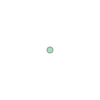

In [6]:
# shapely defines a point by its x and y coordinates:
Point(0, 0)

In [8]:
# It can calculate distance between shapely objects, such as two points

a = Point(0, 0)
b = Point(1, 0)

# taking a and measuring distance to point b
a.distance(b)

1.0

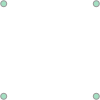

In [10]:
# Multiple points can be placed into a single object
MultiPoint([(0, 0), (0, 1), (1, 1), (1, 0)])

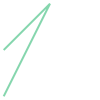

In [11]:
line = LineString([(0, 0), (1, 2), (0, 1)])

line

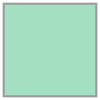

In [12]:
# poligon is also defined by the series of points

pol = Polygon([(0, 0), (0, 1), (1, 1), (1, 0)])
pol

In [13]:
# polygon have attribute like area
pol.area

1.0

## Geopandas basics

Another tool working with geospatial data is **geopandas**. Pandas *DataFrames* represent tabular datasets. Similarly geopandas *DataFrames* represent tabular data with two extensions.

- The geometry column defines a point, or polygon associated with the rest of the columst. This column is a collection of shapely objects. Whatever you can do with shapely objects you can
also do with a geometry object.
- The CRS is the coordinate reference system of the geometry column that tells us where a point, line or polygon lies on a earth surface. Geopandas maps a geometry onto the earth surface **(WGS84)**.

In [17]:
# importing library
import matplotlib
import geopandas as gdp

In [18]:
world_gdf = gdp.read_file(
    gdp.datasets.get_path("natualearth_lowres")
)

world_gdf

AttributeError: The geopandas.dataset has been deprecated and was removed in GeoPandas 1.0. New sample datasets are now available in the geodatasets package (https://geodatasets.readthedocs.io/en/latest/)

In [23]:
!pip install geodatasets

In [25]:
import geodatasets

In [26]:
geodatasets.data

{'geoda': {'airbnb': {'url': 'https://geodacenter.github.io/data-and-lab//data/airbnb.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.airbnb',
   'description': 'Airbnb rentals, socioeconomics, and crime in Chicago',
   'geometry_type': 'Polygon',
   'nrows': 77,
   'ncols': 21,
   'details': 'https://geodacenter.github.io/data-and-lab//airbnb/',
   'hash': 'a2ab1e3f938226d287dd76cde18c00e2d3a260640dd826da7131827d9e76c824',
   'filename': 'airbnb.zip'},
  'atlanta': {'url': 'https://geodacenter.github.io/data-and-lab//data/atlanta_hom.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.atlanta',
   'description': 'Atlanta, GA region homicide counts and rates',
   'geometry_type': 'Polygon',
   'nrows': 90,
   'ncols': 24,
   'details': 'https://geodacenter.github.io/data-and-lab//atlanta_old/',
   'hash': 'a33a76e12168fe84361e60c88a9df4856730487305846c559715c89b1a2b5e09',
   'filename': 'atlanta_hom.zip',
   'members': ['atlanta_hom/atl_hom.geojson']},
  'cars': {'url': 'https://geodacenter.github.io/data-and-lab//data/Abandoned_Vehicles_Map.csv',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.cars',
   'description': '2011 abandoned vehicles in Chicago (311 complaints).',
   'geometry_type': 'Point',
   'nrows': 137867,
   'ncols': 21,
   'details': 'https://geodacenter.github.io/data-and-lab//1-source-and-description/',
   'hash': '6a0b23bc7eda2dcf1af02d43ccf506b24ca8d8c6dc2fe86a2a1cc051b03aae9e',
   'filename': 'Abandoned_Vehicles_Map.csv'},
  'charleston1': {'url': 'https://geodacenter.github.io/data-and-lab//data/CharlestonMSA.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.charleston1',
   'description': '2000 Census Tract Data for Charleston, SC MSA and counties',
   'geometry_type': 'Polygon',
   'nrows': 117,
   'ncols': 31,
   'details': 'https://geodacenter.github.io/data-and-lab//charleston-1_old/',
   'hash': '4a4fa9c8dd4231ae0b2f12f24895b8336bcab0c28c48653a967cffe011f63a7c',
   'filename': 'CharlestonMSA.zip',
   'members': ['CharlestonMSA/sc_final_census2.gpkg']},
  'charleston2': {'url': 'https://geodacenter.github.io/data-and-lab//data/CharlestonMSA2.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.charleston2',
   'description': '1998 and 2001 Zip Code Business Patterns (Census Bureau) for Charleston, SC MSA',
   'geometry_type': 'Polygon',
   'nrows': 42,
   'ncols': 60,
   'details': 'https://geodacenter.github.io/data-and-lab//charleston2/',
   'hash': '056d5d6e236b5bd95f5aee26c77bbe7d61bd07db5aaf72866c2f545205c1d8d7',
   'filename': 'CharlestonMSA2.zip',
   'members': ['CharlestonMSA2/CharlestonMSA2.gpkg']},
  'chicago_health': {'url': 'https://geodacenter.github.io/data-and-lab//data/comarea.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.chicago_health',
   'description': 'Chicago Health + Socio-Economics',
   'geometry_type': 'Polygon',
   'nrows': 77,
   'ncols': 87,
   'details': 'https://geodacenter.github.io/data-and-lab//comarea_vars/',
   'hash': '4e872adb552786eae2fcd745524696e5e4cd33cc9a6c032471c0e75328871401',
   'filename': 'comarea.zip'},
  'chicago_commpop': {'url': 'https://geodacenter.github.io/data-and-lab//data/chicago_commpop.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.chicago_commpop',
   'description': 'Chicago Community Area Population Percent Change for 2000 and 2010',
   'geometry_type': 'Polygon',
   'nrows': 77,
   'ncols': 9,
   'details': 'https://geodacenter.github.io/data-and-lab//commpop/',
   'hash': '1dbebb50c8ea47e2279ea819ef64ba793bdee2b88e4716bd6c6ec0e0d8e0e05b',
   'filename': 'c

In [30]:
geodatasets.data.query_name('geoda airbnb')

{'url': 'https://geodacenter.github.io/data-and-lab//data/airbnb.zip',
 'license': 'NA',
 'attribution': 'Center for Spatial Data Science, University of Chicago',
 'name': 'geoda.airbnb',
 'description': 'Airbnb rentals, socioeconomics, and crime in Chicago',
 'geometry_type': 'Polygon',
 'nrows': 77,
 'ncols': 21,
 'details': 'https://geodacenter.github.io/data-and-lab//airbnb/',
 'hash': 'a2ab1e3f938226d287dd76cde18c00e2d3a260640dd826da7131827d9e76c824',
 'filename': 'airbnb.zip'}

In [35]:
geodatasets

<module 'geodatasets' from '/data/repo-learning/computer-Science-and-Software-Engineering/real-estate-vis/.venv/lib/python3.13/site-packages/geodatasets/__init__.py'>

In [37]:
geodatasets.crs

AttributeError: module 'geodatasets' has no attribute 'crs'

### References 

References used in this learning:

- [Analyse Geospatial Data in Python](https://www.learndatasci.com/tutorials/geospatial-data-python-geopadas-shapely/)

